In [1]:
!pip install -q tensorflow

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import urllib.request

print("24BAD050-JOHIYA SRI S")
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

text = urllib.request.urlopen(url).read().decode("utf-8")

print("\nOriginal text sample:")
print(text[:500])

text = text.lower()
text = text[:30000]

print("\nTotal characters:", len(text))

tokenizer = Tokenizer(
    num_words=2000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts([text])

total_words = min(len(tokenizer.word_index) + 1, 2000)

print("Vocabulary size:", total_words)

words = text.split()

input_sequences = []

for i in range(1, len(words)):
    sequence = tokenizer.texts_to_sequences(
        [" ".join(words[:i])]
    )[0]

    if len(sequence) > 1:
        input_sequences.append(sequence)

input_sequences = input_sequences[:5000]

print("Number of sequences:", len(input_sequences))

max_sequence_len = min(
    max(len(seq) for seq in input_sequences),
    20
)

print("Maximum sequence length:", max_sequence_len)

input_sequences = np.array(
    pad_sequences(
        input_sequences,
        maxlen=max_sequence_len,
        padding="pre"
    )
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

split = int(0.8 * len(X))

X_train = X[:split]
X_val = X[split:]

y_train = y[:split]
y_val = y[split:]

print("\nTraining input shape:", X_train.shape)
print("Validation input shape:", X_val.shape)
print("Training target shape:", y_train.shape)
print("Validation target shape:", y_val.shape)

24BAD050-JOHIYA SRI S

Original text sample:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor

Total characters: 30000
Vocabulary size: 1466
Number of sequences: 5000
Maximum sequence length: 20

Training input shape: (4000, 19)
Validation input shape: (1000, 19)
Training target shape: (4000,)
Validation target shape: (1000,)


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

print("24BAD050-JOHIYA SRI S")

model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=32,
        input_length=X_train.shape[1]
    ),
    SimpleRNN(64),
    Dense(total_words, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

24BAD050-JOHIYA SRI S


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

24BAD050-JOHIYA SRI S
Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.0342 - loss: 6.7859 - val_accuracy: 0.0370 - val_loss: 6.5632
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0413 - loss: 6.1727 - val_accuracy: 0.0370 - val_loss: 6.6600
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0413 - loss: 6.1312 - val_accuracy: 0.0370 - val_loss: 6.7524
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.0413 - loss: 6.1233 - val_accuracy: 0.0370 - val_loss: 6.7437
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.0410 - loss: 6.0947 - val_accuracy: 0.0370 - val_loss: 6.7281

Final Training Accuracy: 0.04125000163912773
Final Validation Accuracy: 0.03700000047683716
Final Training Loss: 5.990348815917969
Final Validation Loss: 6.72807502746582


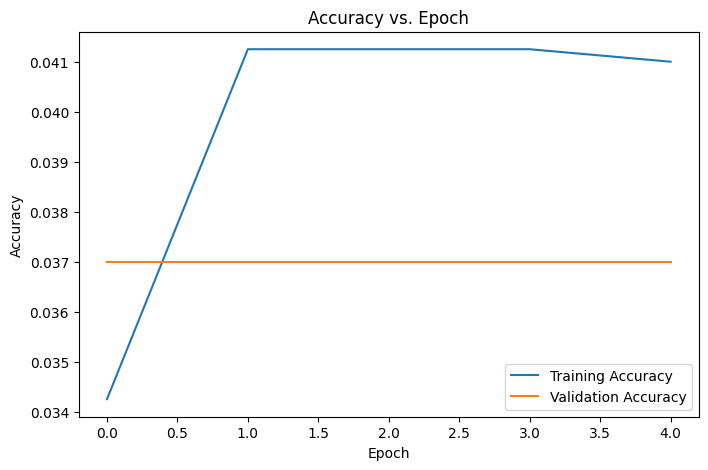

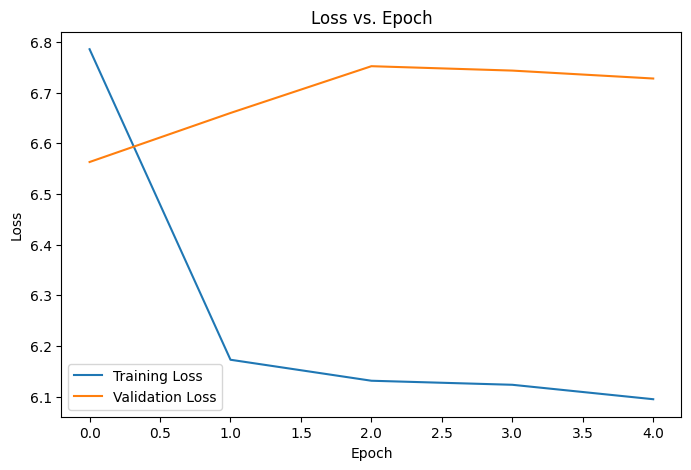

In [3]:
import matplotlib.pyplot as plt

print("24BAD050-JOHIYA SRI S")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64,
    verbose=1
)

train_loss, train_accuracy = model.evaluate(
    X_train, y_train, verbose=0
)

val_loss, val_accuracy = model.evaluate(
    X_val, y_val, verbose=0
)

print("\nFinal Training Accuracy:", train_accuracy)
print("Final Validation Accuracy:", val_accuracy)
print("Final Training Loss:", train_loss)
print("Final Validation Loss:", val_loss)

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [4]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("24BAD050-JOHIYA SRI S")

def generate_text(seed_text, next_words=20):
    generated_text = seed_text.lower()

    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences(
            [generated_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=X_train.shape[1],
            padding="pre"
        )

        predicted_probabilities = model.predict(
            token_list,
            verbose=0
        )

        predicted_word_index = np.argmax(
            predicted_probabilities, axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted_word_index:
                output_word = word
                break

        if output_word == "":
            break

        generated_text += " " + output_word

    return generated_text

seed_inputs = [
    "shall i compare thee",
    "the king",
    "to be or not to be",
    "love is",
    "what is"
]

for seed in seed_inputs:
    generated = generate_text(seed, next_words=20)

    print("\nSeed:", seed)
    print("Generated text:", generated)

24BAD050-JOHIYA SRI S

Seed: shall i compare thee
Generated text: shall i compare thee the the the the the the the the the the the the the the the the the the the the

Seed: the king
Generated text: the king the the the the the the the the the the the the the the the the the the the the

Seed: to be or not to be
Generated text: to be or not to be the the the the the the the the the the the the the the the the the the the the

Seed: love is
Generated text: love is the the the the the the the the the the the the the the the the the the the the

Seed: what is
Generated text: what is the the the the the the the the the the the the the the the the the the the the
